# NyayaSetu — Category Classifier (Cleaned)

This notebook trains the `example_user_problem → category` classifier on the 500-row verified dataset,
correctly merges in the 100-row targeted augmentation set, and evaluates several models.

**Fixed from the previous version:** the augmentation step was accidentally trained on `df["synthetic_query"]`,
a column that is literally the string `"Yes"` for all 500 rows in this dataset (not query text). The real query
text is in `df["example_user_problem"]`. This notebook uses the correct column throughout.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

## 1. Load the base dataset (500 rows, 10 categories x 50 each)

In [2]:
df = pd.read_excel(
    "NyayaSetu_v2_500_balanced_verified_sources.xlsx",
    sheet_name="Legal_Problems_500"
)
print(df.shape)
print(df["category"].value_counts())
df[["category", "example_user_problem"]].head()

(500, 16)
category
Consumer                 50
Cyber Crime              50
Employment               50
Family                   50
Government Services      50
Legal Aid                50
Motor Accident Claims    50
Property                 50
Women's Safety           50
Education                50
Name: count, dtype: int64


,category,example_user_problem
0,Consumer,I bought a phone and the seller refuses to rep...
1,Consumer,The washing machine I purchased stopped workin...
2,Consumer,I bought furniture that arrived damaged and th...
3,Consumer,My new laptop has a manufacturing defect but t...
4,Consumer,The online seller has not refunded my money af...


## 2. Load the targeted augmentation set (100 rows)

These 100 rows were built to reinforce the categories that scored weakest in the first pass
(Consumer, Women's Safety, Property, Employment, Government Services).

In [3]:
aug_df = pd.read_excel(
    "NyayaSetu_targeted_augmentation_100.xlsx",
    sheet_name="Targeted_100"
)
print(aug_df.shape)
print(aug_df["category"].value_counts())
aug_df.head()

(100, 3)
category
Consumer               30
Women's Safety         30
Property               20
Employment             10
Government Services    10
Name: count, dtype: int64


,augmentation_id,category,synthetic_query
0,AUG_001,Consumer,An online store delivered a damaged washing ma...
1,AUG_002,Consumer,I paid for a refrigerator online but the selle...
2,AUG_003,Consumer,A seller sent a different mobile phone model t...
3,AUG_004,Consumer,My purchased laptop stopped working within war...
4,AUG_005,Consumer,An e-commerce platform cancelled my prepaid or...


## 3. Train/test split on the base data, then merge in augmentation (train side only)

In [4]:
text_col = "example_user_problem"
target_col = "category"

X = df[text_col].astype(str)
y = df[target_col].astype(str)

# 80/20 split, stratified so every category is represented proportionally in the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Merge augmentation into TRAIN ONLY -- test set stays untouched so accuracy is honest
X_train_aug = pd.concat([X_train, aug_df["synthetic_query"].astype(str)], ignore_index=True)
y_train_aug = pd.concat([y_train, aug_df["category"].astype(str)], ignore_index=True)

print("Base training samples:", len(X_train))
print("Augmented training samples:", len(X_train_aug))
print("Test samples (untouched):", len(X_test))

Base training samples: 400
Augmented training samples: 500
Test samples (untouched): 100


## 4. Train and compare candidate models

In [5]:
models = {
    "Decision Tree": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
        ("model", DecisionTreeClassifier(max_depth=20, random_state=42))
    ]),
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
        ("model", LogisticRegression(C=2, max_iter=2000))
    ]),
    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), sublinear_tf=True)),
        ("model", LinearSVC(C=1))
    ]),
}

results = {}

for name, pipe in models.items():
    pipe.fit(X_train_aug, y_train_aug)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="macro", zero_division=0)
    rec = recall_score(y_test, pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, pred, average="macro", zero_division=0)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "Macro F1": f1}

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"Macro F1 : {f1:.4f}\n")

pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)

Decision Tree
Accuracy : 0.4100
Precision: 0.8596
Recall   : 0.4100
Macro F1 : 0.4602

Logistic Regression
Accuracy : 0.7600
Precision: 0.7755
Recall   : 0.7600
Macro F1 : 0.7607

Linear SVM
Accuracy : 0.8400
Precision: 0.8444
Recall   : 0.8400
Macro F1 : 0.8396



,Accuracy,Precision,Recall,Macro F1
Linear SVM,0.84,0.844394,0.84,0.839554
Logistic Regression,0.76,0.775526,0.76,0.760740
Decision Tree,0.41,0.859560,0.41,0.460238


## 5. Final model: Linear SVM

Best accuracy of the three, and it was already the strongest model before augmentation was fixed.

In [6]:
final_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), sublinear_tf=True)),
    ("model", LinearSVC(C=1))
])
final_model.fit(X_train_aug, y_train_aug)

y_pred = final_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, zero_division=0))

Final Accuracy: 0.84

                       precision    recall  f1-score   support

             Consumer       0.80      0.80      0.80        10
          Cyber Crime       0.82      0.90      0.86        10
            Education       0.75      0.90      0.82        10
           Employment       0.89      0.80      0.84        10
               Family       0.90      0.90      0.90        10
  Government Services       1.00      0.80      0.89        10
            Legal Aid       0.90      0.90      0.90        10
Motor Accident Claims       0.91      1.00      0.95        10
             Property       0.78      0.70      0.74        10
       Women's Safety       0.70      0.70      0.70        10

             accuracy                           0.84       100
            macro avg       0.84      0.84      0.84       100
         weighted avg       0.84      0.84      0.84       100



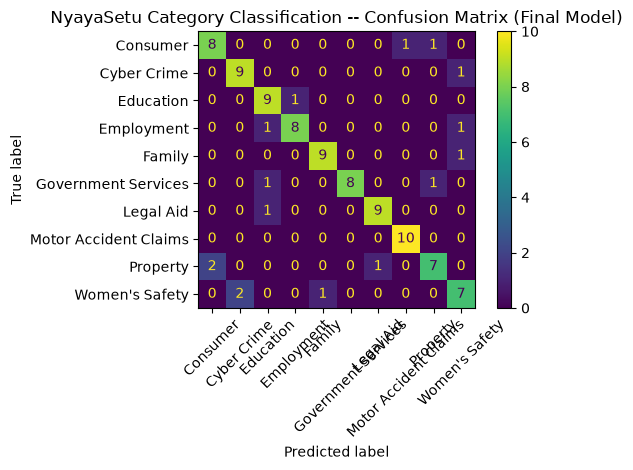

In [7]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
plt.title("NyayaSetu Category Classification -- Confusion Matrix (Final Model)")
plt.tight_layout()
plt.show()

## 6. Classifier wrapper for use in the app / triage pipeline

In [8]:
def classify_category(query):
    query = str(query)
    predicted = final_model.predict([query])[0]
    decision = final_model.decision_function([query])[0]
    # LinearSVC has no predict_proba; use softmax over decision scores as a confidence proxy
    import numpy as np
    exp_scores = np.exp(decision - decision.max())
    probs = exp_scores / exp_scores.sum()
    confidence = probs.max()
    return predicted, confidence

# quick sanity check
for q in [
    "My employer has not paid my salary for three months.",
    "I bought a refrigerator online and received a damaged product.",
    "A woman is being harassed and threatened by someone.",
    "My landlord is refusing to return my security deposit.",
]:
    cat, conf = classify_category(q)
    print(f"{q}\n  -> {cat}  (confidence: {conf:.2f})\n")

My employer has not paid my salary for three months.
  -> Employment  (confidence: 0.41)

I bought a refrigerator online and received a damaged product.
  -> Consumer  (confidence: 0.33)

A woman is being harassed and threatened by someone.
  -> Women's Safety  (confidence: 0.32)

My landlord is refusing to return my security deposit.
  -> Property  (confidence: 0.29)



In [9]:
# ==========================================
# CELL 8 — CALIBRATED CLASSIFIER
# ==========================================

from sklearn.calibration import CalibratedClassifierCV
import numpy as np

# Calibrate the already trained LinearSVC
calibrated_model = CalibratedClassifierCV(
    final_model,
    method="sigmoid",
    cv=5
)

# Fit calibration using the training data
calibrated_model.fit(X_train, y_train)


def classify_category(query):
    query = str(query)

    # Predicted category
    predicted = calibrated_model.predict([query])[0]

    # Calibrated probabilities
    probabilities = calibrated_model.predict_proba([query])[0]

    # Highest probability
    confidence = probabilities.max()

    return predicted, confidence


# ==========================================
# QUICK SANITY CHECK
# ==========================================

test_queries = [
    "My employer has not paid my salary for three months.",
    "I bought a refrigerator online and received a damaged product.",
    "A woman is being harassed and threatened by someone.",
    "My landlord is refusing to return my security deposit.",
]

for q in test_queries:
    cat, conf = classify_category(q)

    print(
        f"{q}\n"
        f"  -> {cat}  (confidence: {conf:.2%})\n"
    )

My employer has not paid my salary for three months.
  -> Employment  (confidence: 78.23%)

I bought a refrigerator online and received a damaged product.
  -> Consumer  (confidence: 65.26%)

A woman is being harassed and threatened by someone.
  -> Women's Safety  (confidence: 62.65%)

My landlord is refusing to return my security deposit.
  -> Property  (confidence: 63.89%)



In [10]:
import json
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load the new legal corpus
with open("statute_corpus_v1.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)

print(f"Loaded {len(corpus)} legal chunks")

# Create searchable text for each legal chunk
corpus_texts = [
    f"{item['topic']} {item['act']} {item['section']} "
    f"{item['section_title']} {item['text']} "
    f"{' '.join(item['coverage_topics'])}"
    for item in corpus
]

# TF-IDF vectorizer for legal retrieval
retrieval_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    stop_words="english"
)

corpus_matrix = retrieval_vectorizer.fit_transform(corpus_texts)


def retrieve_legal_chunks(query, category, top_k=3):
    """
    Retrieve the most relevant legal chunks
    from the predicted category only.
    """

    query = str(query)

    # Find chunks belonging to predicted category
    category_indices = [
        i for i, item in enumerate(corpus)
        if item["category"] == category
    ]

    if not category_indices:
        return []

    # Vectorize user query
    query_vector = retrieval_vectorizer.transform([query])

    # Calculate similarity against entire corpus
    similarities = cosine_similarity(
        query_vector,
        corpus_matrix
    )[0]

    # Keep only chunks from predicted category
    ranked_indices = sorted(
        category_indices,
        key=lambda i: similarities[i],
        reverse=True
    )

    results = []

    for i in ranked_indices[:top_k]:
        item = corpus[i].copy()
        item["similarity_score"] = float(similarities[i])
        results.append(item)

    return results

Loaded 30 legal chunks


In [11]:
test_queries = [
    "My employer has not paid my salary for three months.",
    "I bought a refrigerator online and received a damaged product.",
    "A woman is being harassed and threatened by someone.",
    "My landlord is refusing to return my security deposit."
]

for query in test_queries:

    category, confidence = classify_category(query)

    results = retrieve_legal_chunks(
        query,
        category,
        top_k=3
    )

    print("=" * 80)
    print("QUERY:", query)
    print(f"CATEGORY: {category}")
    print(f"CONFIDENCE: {confidence:.2%}")

    for rank, result in enumerate(results, 1):
        print(f"\n{rank}. {result['chunk_id']}")
        print(f"   Act: {result['act']}")
        print(f"   Section: {result['section']}")
        print(f"   Topic: {result['topic']}")
        print(f"   Similarity: {result['similarity_score']:.2%}")

QUERY: My employer has not paid my salary for three months.
CATEGORY: Employment
CONFIDENCE: 78.23%

1. EMPLOYMENT_001
   Act: Code on Wages, 2019; Industrial Relations Code, 2020
   Section: Section 17, Code on Wages; Section 59, Industrial Relations Code
   Topic: Unpaid wages / salary dues
   Similarity: 18.70%

2. EMPLOYMENT_003
   Act: Industrial Relations Code, 2020
   Section: Section 59 and dispute-resolution provisions
   Topic: Industrial dispute / termination
   Similarity: 5.62%

3. EMPLOYMENT_002
   Act: Code on Wages, 2019
   Section: Sections 5, 14 and 18
   Topic: Minimum wages / deductions / overtime
   Similarity: 0.00%
QUERY: I bought a refrigerator online and received a damaged product.
CATEGORY: Consumer
CONFIDENCE: 65.26%

1. CONSUMER_001
   Act: Consumer Protection Act, 2019
   Section: Section 35
   Topic: Defective product / damaged goods / warranty
   Similarity: 31.95%

2. CONSUMER_002
   Act: Consumer Protection Act, 2019
   Section: Sections 34, 47, 58
   T

In [13]:
!pip install groq python-dotenv

  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.4-py3-none-any.whl.metadata (2.6 kB)
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 995.6 kB/s eta 0:00:02
   ------------------------------ --------- 1.6/2.0 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 2.6 MB/s  0:00:01
Using cached

In [14]:
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
import os
from groq import Groq

# Load Groq API key
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is not configured.")

client = Groq(api_key=GROQ_API_KEY)

print("Groq client configured successfully.")

Groq client configured successfully.


In [19]:
def generate_legal_guidance(query, category, confidence, retrieved_chunks):
    """
    Generate grounded legal guidance using only the retrieved corpus chunks.
    """

    if not retrieved_chunks:
        return "No relevant legal information was retrieved."

    # Prepare retrieved legal context
    legal_context = ""

    for i, chunk in enumerate(retrieved_chunks, 1):
        legal_context += f"""
LEGAL CHUNK {i}
Chunk ID: {chunk['chunk_id']}
Category: {chunk['category']}
Topic: {chunk['topic']}
Act: {chunk['act']}
Section: {chunk['section']}
Section Title: {chunk['section_title']}
Legal Text: {chunk['text']}
Pathway: {chunk['pathway']}
Documents/Evidence: {chunk['documents']}
Authority: {chunk['authority']}
Source: {chunk['source_url']}
Verification Status: {chunk['verification_status']}
"""

    prompt = f"""
You are the legal-information generation component of NyayaSetu,
an AI-based Legal Triage and Justice Navigation System for India.

USER GRIEVANCE:
{query}

PREDICTED CATEGORY:
{category}

CLASSIFIER CONFIDENCE:
{confidence:.2%}

RETRIEVED LEGAL CORPUS:
{legal_context}

IMPORTANT RULES:
1. Use ONLY the retrieved legal corpus provided above.
2. Do not invent or add legal sections, Acts, authorities, procedures,
   deadlines, penalties, or legal claims that are not supported by the corpus.
3. Do not present the response as a substitute for professional legal advice.
4. If the retrieved information is insufficient or uncertain, clearly say so.
5. Keep the response practical and easy for a person without legal
   knowledge to understand.
6. Preserve the distinction between legal information and legal advice.
7. Mention the relevant Act and Section exactly as provided in the corpus.
8. Do not claim that the user will definitely win a case or receive a
   particular remedy.

FORMAT YOUR RESPONSE AS:

LEGAL TRIAGE RESULT

Category:
[category]

Confidence:
[confidence]

Relevant Legal Provision:
[Act and Section]

Why It May Be Relevant:
[brief explanation based only on retrieved corpus]

Recommended Pathway:
[practical next step based only on corpus]

Documents / Evidence:
[list the relevant documents]

Possible Authority / Forum:
[authority from corpus]

Source:
[source URL from corpus]

Important:
[include verification limitations if present]

Disclaimer:
This is general legal information, not legal advice. Laws and procedures
may vary depending on the facts and jurisdiction. Verify the applicable
law and consult a qualified legal professional or appropriate legal
authority where necessary.
"""

    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[
            {
                "role": "system",
                "content": "You provide grounded legal-information responses using only supplied corpus evidence."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.1,
        max_tokens=1000
    )

    return response.choices[0].message.content

In [18]:
models = client.models.list()

print("Available Groq models:\n")

for model in models.data:
    print(model.id)

Available Groq models:

meta-llama/llama-prompt-guard-2-22m
canopylabs/orpheus-arabic-saudi
canopylabs/orpheus-v1-english
qwen/qwen3.8-27b
meta-llama/llama-prompt-guard-2-86m
openai/gpt-oss-safeguard-20b
allam-2-7b
qwen/qwen3.6-27b
groq/compound-mini
openai/gpt-oss-120b
groq/compound
whisper-large-v3
openai/gpt-oss-20b
whisper-large-v3-turbo


In [20]:
query = "My employer has not paid my salary for three months."

category, confidence = classify_category(query)

retrieved_chunks = retrieve_legal_chunks(
    query,
    category,
    top_k=3
)

answer = generate_legal_guidance(
    query,
    category,
    confidence,
    retrieved_chunks
)

print("=" * 80)
print("USER QUERY")
print("=" * 80)
print(query)

print("\n" + "=" * 80)
print("NYAYASETU RESPONSE")
print("=" * 80)
print(answer)

USER QUERY
My employer has not paid my salary for three months.

NYAYASETU RESPONSE
**LEGAL TRIAGE RESULT**

**Category:**  
Employment  

**Confidence:**  
78.23%  

**Relevant Legal Provision:**  
- Code on Wages, 2019 – **Section 17** (Time limit for payment of wages)  
- Industrial Relations Code, 2020 – **Section 59** (Recovery of money due from employer)  

**Why It May Be Relevant:**  
Section 17 of the Code on Wages sets a statutory time‑limit for the employer to pay wages.  
Section 59 of the Industrial Relations Code provides a specific mechanism for a worker to recover wages that have not been paid, allowing an application to the appropriate government or labour authority. Because you have not received salary for three months, both provisions are directly applicable to your situation.  

**Recommended Pathway:**  
1. **Gather evidence** (see Documents/Evidence below).  
2. **File a claim** for recovery of the unpaid salary under **Section 59, Industrial Relations Code** with

In [21]:
test_queries = [
    "My employer has not paid my salary for three months.",
    "I bought a refrigerator online and received a damaged product.",
    "A woman is being harassed and threatened by someone.",
    "My landlord is refusing to return my security deposit."
]

for query in test_queries:

    category, confidence = classify_category(query)

    retrieved_chunks = retrieve_legal_chunks(
        query,
        category,
        top_k=3
    )

    answer = generate_legal_guidance(
        query,
        category,
        confidence,
        retrieved_chunks
    )

    print("\n" + "=" * 100)
    print("QUERY:", query)
    print("CATEGORY:", category)
    print(f"CONFIDENCE: {confidence:.2%}")

    print("\n--- RETRIEVED CHUNKS ---")

    for rank, result in enumerate(retrieved_chunks, 1):
        print(
            f"{rank}. {result['chunk_id']} | "
            f"{result['act']} | "
            f"{result['section']} | "
            f"Similarity: {result['similarity_score']:.2%}"
        )

    print("\n--- GENERATED GUIDANCE ---")
    print(answer)


QUERY: My employer has not paid my salary for three months.
CATEGORY: Employment
CONFIDENCE: 78.23%

--- RETRIEVED CHUNKS ---
1. EMPLOYMENT_001 | Code on Wages, 2019; Industrial Relations Code, 2020 | Section 17, Code on Wages; Section 59, Industrial Relations Code | Similarity: 18.70%
2. EMPLOYMENT_003 | Industrial Relations Code, 2020 | Section 59 and dispute-resolution provisions | Similarity: 5.62%
3. EMPLOYMENT_002 | Code on Wages, 2019 | Sections 5, 14 and 18 | Similarity: 0.00%

--- GENERATED GUIDANCE ---
**LEGAL TRIAGE RESULT**

**Category:**  
Employment  

**Confidence:**  
78.23%  

**Relevant Legal Provision:**  
- **Code on Wages, 2019 – Section 17** (Time limit for payment of wages)  
- **Industrial Relations Code, 2020 – Section 59** (Recovery of money due from employer)  

**Why It May Be Relevant:**  
Section 17 of the Code on Wages sets a statutory time‑limit within which an employer must pay wages.  
Section 59 of the Industrial Relations Code provides a specific me